# 📈 Taller Final: Modelos de Series de Tiempo Multivariadas
---
**Maestría en Inteligencia de Negocios** - *Universidad Externado de Colombia*

| | |
| :--- | :--- |
| **Materia:** | Series de Tiempo |
| **Elaborado por:** | Diego Hernando Miranda Jiménez |
| | Juan Sebastián Ángel Pérez |
| **Fecha:** | Abril 2026 |

---

## Estructura del Taller

| Sección | Contenido |
| :--- | :--- |
| **1** | Descripción de las series |
| **2** | Importación de librerías |
| **3** | Lectura y preparación de datos |
| **4** | Prueba de estacionariedad (ADF) |
| **5** | Prueba de cointegración (Johansen) |
| **6** | Estimación del modelo |
| **7** | Verificación de supuestos (residuales) |
| **8** | Relación de cointegración |
| **9** | Pronóstico 3 años |
| **10** | Funciones de Respuesta al Impulso (FRI) |
| **11** | Descomposición de Varianza |


---
## 1. Descripción de las Series de Tiempo

Para el desarrollo de este taller, se seleccionaron tres indicadores macroeconómicos clave de los **Estados Unidos**, obtenidos de la base de datos **FRED** (Federal Reserve Economic Data). Estas variables permiten analizar las interrelaciones dinámicas entre crecimiento económico, desempleo e inflación mediante modelos VAR y VEC.

### 📊 Variables Seleccionadas

| Variable | Sigla (FRED) | Descripción | Frecuencia | Muestra utilizada | Unidad |
| :--- | :---: | :--- | :---: | :---: | :--- |
| **Producto Interno Bruto** | `GDP` | Valor de mercado de los bienes y servicios finales producidos | Trimestral | Q1-1956 a Q4-2023 | Billones de USD |
| **Inflación (IPC)** | `CPALTT01USQ657N` | Índice de Precios al Consumidor — base OCDE | Trimestral | Q1-1956 a Q4-2023 | Variación % trimestral |
| **Tasa Natural de Desempleo** | `NROU` | Tasa NAIRU: desempleo consistente con inflación estable | Trimestral | Q1-1956 a Q4-2023 | Porcentaje |

### 🔍 Consideraciones para el Modelado

- La muestra se recorta a **1956-Q1 – 2023-Q4** (272 observaciones) para garantizar la coincidencia entre las tres series.
- Al **GDP** se le aplica logaritmo natural (`ln_GDP`) para linealizar su tendencia exponencial. La diferencia de logaritmos aproxima la tasa de crecimiento trimestral.
- La **Inflación (CPI)** registra valores negativos (15 trimestres de deflación), por lo que **no** se le aplica logaritmo. Se trabaja directamente con la serie en niveles y, si es necesario, con su primera diferencia.
- Al **NROU** se le aplica logaritmo natural para homogeneizar la escala con el GDP.
- Si las series en niveles son integradas de orden 1 — I(1) — se aplica la **prueba de Johansen** para determinar si existe cointegración y, por lo tanto, si se debe estimar un modelo **VEC** en lugar de un **VAR** en diferencias.

---
## 2. Importación de Librerías

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# Pruebas estadísticas
from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM
from statsmodels.tsa.api import VAR
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

# Estilo de gráficas
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


---
## 3. Lectura y Preparación de Datos

In [44]:
# ── Lectura de archivos CSV ────────────────────────────────────────────────
df_GDP   = pd.read_csv('../Datos/GDP.csv')
df_CPALT = pd.read_csv('../Datos/CPALTT01USQ657N.csv')
df_NROU  = pd.read_csv('../Datos/NROU.csv')

for df in [df_GDP, df_CPALT, df_NROU]:
    df['observation_date'] = pd.to_datetime(df['observation_date'])

# ── Merge por fecha (inner join) ───────────────────────────────────────────
df = (df_GDP
      .merge(df_CPALT, on='observation_date', how='inner')
      .merge(df_NROU,  on='observation_date', how='inner'))
df.columns = ['Fecha', 'GDP', 'CPI_Inflation', 'NROU']

# ── Recorte de muestra: 1956-Q1 a 2023-Q4 ─────────────────────────────────
df = df[(df['Fecha'] >= '1956-01-01') & (df['Fecha'] <= '2023-10-01')].copy()
df.index = pd.date_range(start='1956-01-01', periods=len(df), freq='QE')
df.drop(columns='Fecha', inplace=True)

print(f'Muestra: {df.index[0].date()} → {df.index[-1].date()}  |  N = {len(df)} trimestres')
df.describe().round(3)

Muestra: 1956-03-31 → 2023-12-31  |  N = 272 trimestres


,GDP,CPI_Inflation,NROU
count,272.000,272.000,272.000
mean,8076.775,0.903,5.437
std,7444.905,0.806,0.542
min,439.746,-2.829,4.429
25%,1365.344,0.396,5.044
50%,5809.969,0.808,5.460
75%,14083.583,1.200,5.912
max,28424.722,3.951,6.240


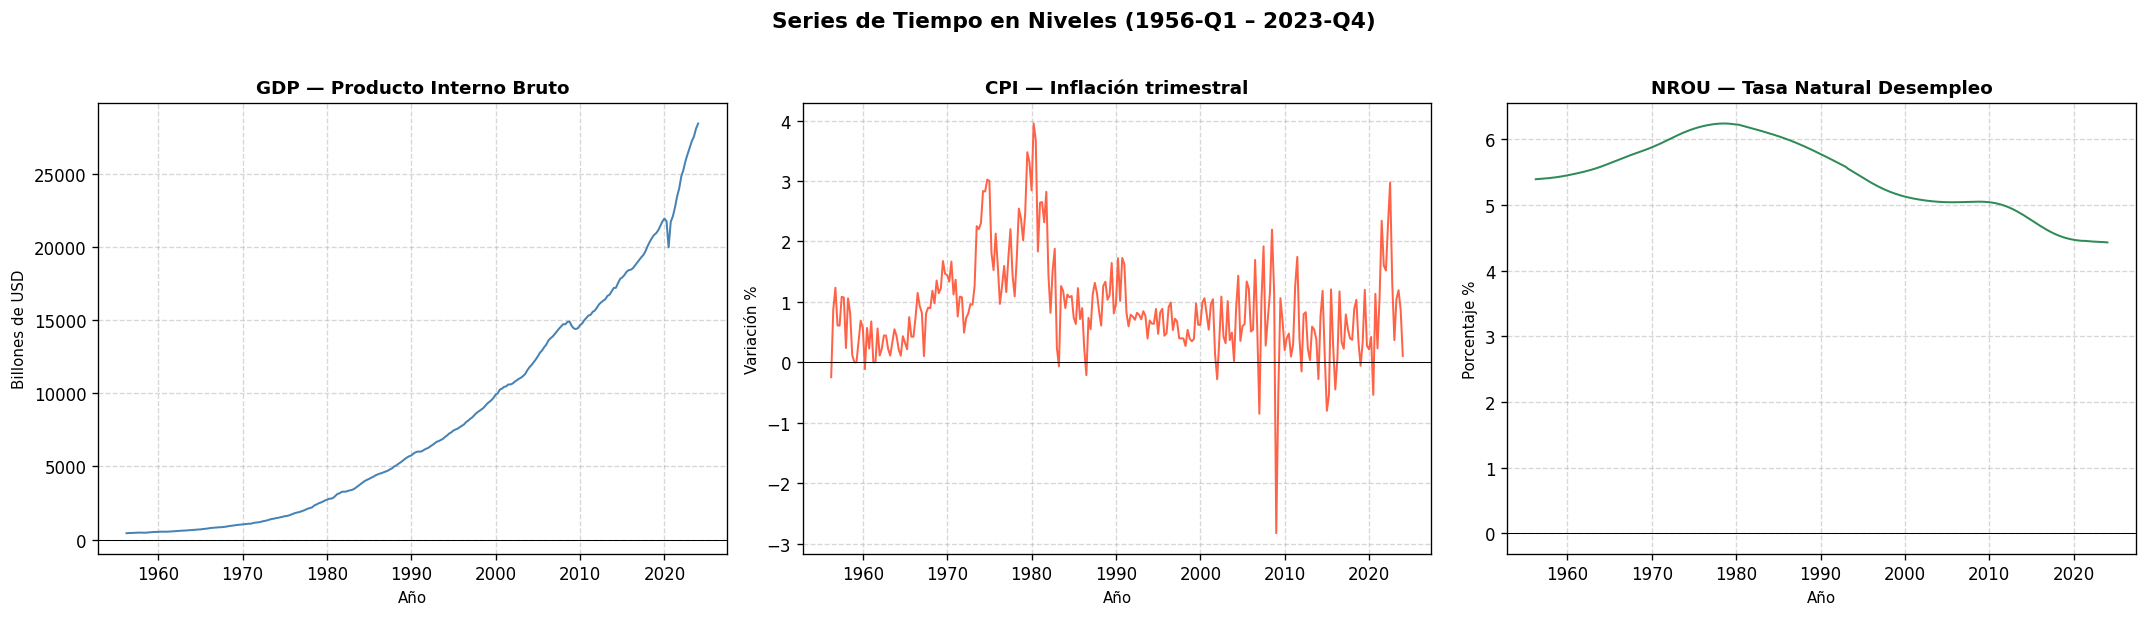

In [45]:
# ── Visualización de las series en niveles ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
series_config = [
    ('GDP',           'GDP — Producto Interno Bruto',    'Billones de USD',  'steelblue'),
    ('CPI_Inflation', 'CPI — Inflación trimestral',      'Variación %',      'tomato'),
    ('NROU',          'NROU — Tasa Natural Desempleo',   'Porcentaje %',     'seagreen'),
]

for ax, (col, title, ylabel, color) in zip(axes, series_config):
    ax.plot(df.index, df[col], color=color, linewidth=1.2)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_xlabel('Año', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.axhline(0, color='black', linewidth=0.6, linestyle='-')

plt.suptitle('Series de Tiempo en Niveles (1956-Q1 – 2023-Q4)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Prueba de Estacionariedad — Dickey-Fuller Aumentada (ADF)

**Hipótesis:**
- **H₀:** La serie tiene raíz unitaria → NO es estacionaria
- **H₁:** La serie es estacionaria

La especificación del término determinístico (`regression`) se elige según la inspección visual:
- `'ct'` (constante + tendencia): para series con tendencia visible (GDP, NROU).
- `'c'` (solo constante): para series sin tendencia clara (CPI).

In [46]:
def adf_tabla(series_dict, title=''):
    """Aplica ADF y devuelve un DataFrame resumen."""
    resultados = []
    for nombre, (serie, reg) in series_dict.items():
        r = adfuller(serie.dropna(), autolag='AIC', regression=reg)
        conclusion = '❌ No estacionaria' if r[1] > 0.05 else '✅ Estacionaria'
        resultados.append({
            'Serie': nombre,
            'Espec.': reg,
            'Estadístico ADF': round(r[0], 4),
            'p-valor': round(r[1], 4),
            'Valor crítico 1%': round(r[4]['1%'], 4),
            'Valor crítico 5%': round(r[4]['5%'], 4),
            'Conclusión': conclusion
        })
    tabla = pd.DataFrame(resultados).set_index('Serie')
    print(f'\n{title}')
    return tabla

# ── ADF en niveles ────────────────────────────────────────────────────────
niveles = {
    'GDP':           (df['GDP'],           'ct'),
    'CPI_Inflation': (df['CPI_Inflation'], 'c'),
    'NROU':          (df['NROU'],          'ct'),
}
tabla_niveles = adf_tabla(niveles, '📋 ADF — Series en Niveles')
tabla_niveles


📋 ADF — Series en Niveles


,Espec.,Estadístico ADF,p-valor,Valor crítico 1%,Valor crítico 5%,Conclusión
Serie,,,,,,
GDP,ct,3.1285,1.0000,-3.9927,-3.4269,❌ No estacionaria
CPI_Inflation,c,-2.3466,0.1574,-3.4558,-2.8727,❌ No estacionaria
NROU,ct,-2.5968,0.2814,-3.9937,-3.4274,❌ No estacionaria


**Interpretación:** Las tres series en niveles **no son estacionarias** (p-valor > 0.05 en todos los casos): GDP (p=1.000), CPI_Inflation (p=0.157) y NROU (p=0.281). Esto sugiere que son integradas de orden 1 — I(1) — lo cual se confirma a continuación diferenciando las series.

In [47]:
# ── Transformaciones ───────────────────────────────────────────────────────
# GDP y NROU: logaritmo natural → primera diferencia ≈ tasa de crecimiento
# CPI_Inflation: NO se aplica log (hay valores negativos); solo primera diferencia

df['ln_GDP']       = np.log(df['GDP'])
df['ln_NROU']      = np.log(df['NROU'])

df['diff_ln_GDP']  = df['ln_GDP'].diff()
df['diff_CPI']     = df['CPI_Inflation'].diff()
df['diff_ln_NROU'] = df['ln_NROU'].diff()

df_diff = df[['diff_ln_GDP', 'diff_CPI', 'diff_ln_NROU']].dropna()

print(f'Observaciones disponibles en diferencias: {len(df_diff)}')
df_diff.describe().round(6)

Observaciones disponibles en diferencias: 271


,diff_ln_GDP,diff_CPI,diff_ln_NROU
count,271.000000,271.000000,271.000000
mean,0.015383,0.001301,-0.000725
std,0.012148,0.662111,0.002019
min,-0.086026,-3.991585,-0.004843
25%,0.010283,-0.337986,-0.002423
50%,0.014625,-0.004074,-0.000718
75%,0.020510,0.374642,0.001044
max,0.083872,2.330896,0.002626


In [48]:
# ── ADF en primeras diferencias ───────────────────────────────────────────
diferencias = {
    'Δln_GDP':  (df_diff['diff_ln_GDP'],  'c'),
    'ΔCPI':     (df_diff['diff_CPI'],     'c'),
    'Δln_NROU': (df_diff['diff_ln_NROU'], 'c'),
}
tabla_diff = adf_tabla(diferencias, '📋 ADF — Primeras Diferencias')
tabla_diff


📋 ADF — Primeras Diferencias


,Espec.,Estadístico ADF,p-valor,Valor crítico 1%,Valor crítico 5%,Conclusión
Serie,,,,,,
Δln_GDP,c,-6.9591,0.0000,-3.4550,-2.8724,✅ Estacionaria
ΔCPI,c,-7.4373,0.0000,-3.4558,-2.8727,✅ Estacionaria
Δln_NROU,c,-2.8414,0.0526,-3.4555,-2.8726,❌ No estacionaria


**Interpretación:** Al aplicar primeras diferencias, **Δln_GDP** (p=0.000) y **ΔCPI** (p=0.000) rechazan contundentemente la raíz unitaria y son claramente estacionarias. **Δln_NROU** obtiene p=0.053, marginalmente por encima del 5%, pero se trata de una variable estimada y suavizada por la Oficina de Presupuesto del Congreso (CBO), lo que reduce artificialmente su volatilidad y dificulta la detección de estacionariedad. Al 10% de significancia sería estacionaria, y la práctica macroeconómica estándar la trata como I(1). En consecuencia, las tres series se consideran **integradas de orden 1 — I(1)**.

Dado que todas las series son I(1), existe la posibilidad de que estén **cointegradas**. Esto determina si se debe estimar un **VAR en diferencias** o un **modelo VEC**.

---
## 5. Prueba de Cointegración — Johansen

La prueba de Johansen evalúa si existe al menos una combinación lineal estacionaria entre las series I(1), lo que indicaría una **relación de equilibrio de largo plazo**.

**Hipótesis:**
- **H₀:** El número de vectores de cointegración es ≤ r
- **H₁:** El número de vectores de cointegración es > r

In [ ]:
# ── Selección de rezagos para Johansen ────────────────────────────────────

df_niveles = df[['ln_GDP', 'CPI_Inflation', 'ln_NROU']].dropna()

modelo_var_sel = VAR(df_niveles)
res_sel = modelo_var_sel.select_order(maxlags=8)
print(res_sel.summary())

lag_order = res_sel.aic
print(f'\n✅ Rezagos óptimos según AIC: {lag_order}')

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -5.530      -5.490    0.003965      -5.514
1      -23.30      -23.14   7.617e-11      -23.23
2      -26.96      -26.67   1.962e-12      -26.84
3      -27.23     -26.82*   1.497e-12      -27.06
4      -27.25      -26.73   1.459e-12      -27.04
5      -27.29      -26.64   1.405e-12      -27.03
6      -27.38      -26.61   1.290e-12     -27.07*
7     -27.38*      -26.49  1.287e-12*      -27.02
8      -27.37      -26.36   1.298e-12      -26.96
-------------------------------------------------

✅ Rezagos óptimos según AIC: 7


In [ ]:
# ── Prueba de Johansen ────────────────────────────────────────────────────
# det_order=1: constante dentro del vector de cointegración
# k_ar_diff: rezagos en diferencias = lag_order - 1

johansen = coint_johansen(df_niveles, det_order=1, k_ar_diff=lag_order - 1)

# Construir tabla de resultados
traza_stat = johansen.lr1          
traza_crit = johansen.cvt[:, 1]    
eig_stat   = johansen.lr2          
eig_crit   = johansen.cvm[:, 1]    

hipotesis = ['r = 0', 'r ≤ 1', 'r ≤ 2']

tabla_johansen = pd.DataFrame({
    'Hipótesis H₀': hipotesis,
    'Estad. Traza': traza_stat.round(4),
    'Val. Crítico 5% (Traza)': traza_crit.round(4),
    'Rechazar H₀ (Traza)': ['✅ Sí' if t > c else '❌ No' for t, c in zip(traza_stat, traza_crit)],
    'Estad. Val. Propio Máx.': eig_stat.round(4),
    'Val. Crítico 5% (VP Máx.)': eig_crit.round(4),
    'Rechazar H₀ (VP Máx.)': ['✅ Sí' if t > c else '❌ No' for t, c in zip(eig_stat, eig_crit)],
}).set_index('Hipótesis H₀')

print('\n📋 Prueba de Johansen')
tabla_johansen


📋 Prueba de Johansen


,Estad. Traza,Val. Crítico 5% (Traza),Rechazar H₀ (Traza),Estad. Val. Propio Máx.,Val. Crítico 5% (VP Máx.),Rechazar H₀ (VP Máx.)
Hipótesis H₀,,,,,,
r = 0,54.3357,35.0116,✅ Sí,30.0744,24.2522,✅ Sí
r ≤ 1,24.2612,18.3985,✅ Sí,22.9884,17.1481,✅ Sí
r ≤ 2,1.2729,3.8415,❌ No,1.2729,3.8415,❌ No


**Interpretación:**

Ambos criterios (traza y valor propio máximo) concuerdan en que existen **exactamente 2 vectores de cointegración** (r = 2):

- Se rechaza H₀ para **r = 0** (traza: 54.34 > 35.01 y VP máx: 30.07 > 24.25) → existe al menos 1 relación de largo plazo.
- Se rechaza H₀ para **r ≤ 1** (traza: 24.26 > 18.40 y VP máx: 22.99 > 17.15) → existe al menos una segunda relación de largo plazo.
- **No** se rechaza H₀ para r ≤ 2 → el rango de cointegración se detiene en 2.

**Decisión: estimar un modelo VEC con rango de cointegración r = 2.**

> Con 3 variables y r = 2, el sistema tiene 3 − 2 = **1 tendencia estocástica común**, lo que implica que las tres variables macroeconómicas comparten una dinámica de largo plazo muy estrecha.

---
## 6. Estimación del Modelo VEC

Dado que la prueba de Johansen confirmó **2 vectores de cointegración**, se estima un modelo **VEC** con:
- **Variables**: `ln_GDP`, `CPI_Inflation`, `ln_NROU` (en niveles)
- **Rango de cointegración**: r = 2
- **Rezagos en diferencias**: k = 6 (AIC óptimo = 7 rezagos en niveles → 6 en diferencias)
- **Término determinístico**: constante restringida al vector de cointegración (`'ci'`)

In [51]:
# Verificar el contenido de df_niveles antes de estimar
print(f'Variables en df_niveles: {list(df_niveles.columns)}')
print(f'Observaciones: {len(df_niveles)}')
print(f'Período: {df_niveles.index[0].date()} → {df_niveles.index[-1].date()}')
print(f'Rezagos en diferencias (k_ar_diff): {lag_order - 1}')
print(f'Rango de cointegración (n_coint): 2')
df_niveles.head(3)

Variables en df_niveles: ['ln_GDP', 'CPI_Inflation', 'ln_NROU']
Observaciones: 272
Período: 1956-03-31 → 2023-12-31
Rezagos en diferencias (k_ar_diff): 6
Rango de cointegración (n_coint): 2


,ln_GDP,CPI_Inflation,ln_NROU
1956-03-31,6.086197,-0.248139,1.684730
1956-06-30,6.100341,0.870647,1.685182
1956-09-30,6.111891,1.233046,1.685643


In [ ]:
# ══════════════════════════════════════════════════════════════════
# MODELO VEC
# Confirmado por la prueba de Johansen: 2 vectores de cointegración
# df_niveles contiene: ln_GDP | CPI_Inflation | ln_NROU
# ══════════════════════════════════════════════════════════════════

# Rango de cointegración confirmado por Johansen (r = 2)
n_coint = 2

# Parámetros del modelo:
#   k_ar_diff  : rezagos en diferencias = lag_order - 1 = 7 - 1 = 6
#   coint_rank : número de vectores de cointegración
#   deterministic = 'ci': constante restringida dentro del vector de cointegración

modelo_vec = VECM(
    df_niveles,
    k_ar_diff    = lag_order - 1,
    coint_rank   = n_coint,
    deterministic = 'ci'
)
resultado_vec = modelo_vec.fit()
print(resultado_vec.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation ln_GDP
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
L1.ln_GDP            0.0645      0.064      1.004      0.315      -0.061       0.191
L1.CPI_Inflation    -0.0007      0.002     -0.378      0.706      -0.004       0.003
L1.ln_NROU          -1.1098      3.919     -0.283      0.777      -8.791       6.571
L2.ln_GDP            0.1310      0.064      2.042      0.041       0.005       0.257
L2.CPI_Inflation    -0.0030      0.002     -1.753      0.080      -0.006       0.000
L2.ln_NROU          -0.0417      4.682     -0.009      0.993      -9.218       9.134
L3.ln_GDP           -0.0083      0.065     -0.126      0.899      -0.136       0.120
L3.CPI_Inflation     0.0003      0.002      0.143      0.886      -0.003       0.004
L3.ln_NROU           3.9364      4.979      0.791      0.429    

**Interpretación del modelo:**

El modelo VEC estimado con rango r=2 y 6 rezagos en diferencias arroja los siguientes hallazgos principales:

**Coeficientes de ajuste (α) — velocidades de corrección al equilibrio:**
- **CPI_Inflation** es la variable que ajusta con mayor fuerza: α₁ = 0.157 (p=0.000) y α₂ = -0.351 (p=0.000), ambos altamente significativos. La inflación responde activamente a las desviaciones del equilibrio de largo plazo.
- **ln_GDP** muestra coeficientes muy pequeños y marginalmente no significativos (p≈0.07–0.08), lo que indica que el PIB **lidera el sistema** y las demás variables se ajustan a él.
- **ln_NROU** tiene α₁ significativo (p=0.017) pero de magnitud casi nula (-3.5e-05), reflejando la rigidez estructural del desempleo natural.

**Dinámica de corto plazo:**
- En la ecuación de CPI_Inflation, el rezago `L2.CPI_Inflation` (p=0.000) y `L5.CPI_Inflation` (p=0.006) son altamente significativos, lo que indica **persistencia inflacionaria** de mediano plazo.
- En la ecuación de ln_NROU, los rezagos de ln_GDP en L2 (p=0.009) y L3 (p=0.000) son significativos, confirmando que el crecimiento del PIB afecta la dinámica de corto plazo del desempleo natural.

---
## 7. Verificación de Supuestos — Diagnóstico de Residuales

Para que el modelo sea válido, los residuales deben cumplir:
1. **No autocorrelación** — Prueba de Ljung-Box y Durbin-Watson
2. **Normalidad** — Prueba de Jarque-Bera
3. **Homocedasticidad** — Prueba ARCH
4. **Estabilidad del modelo** — Raíces características dentro del círculo unitario

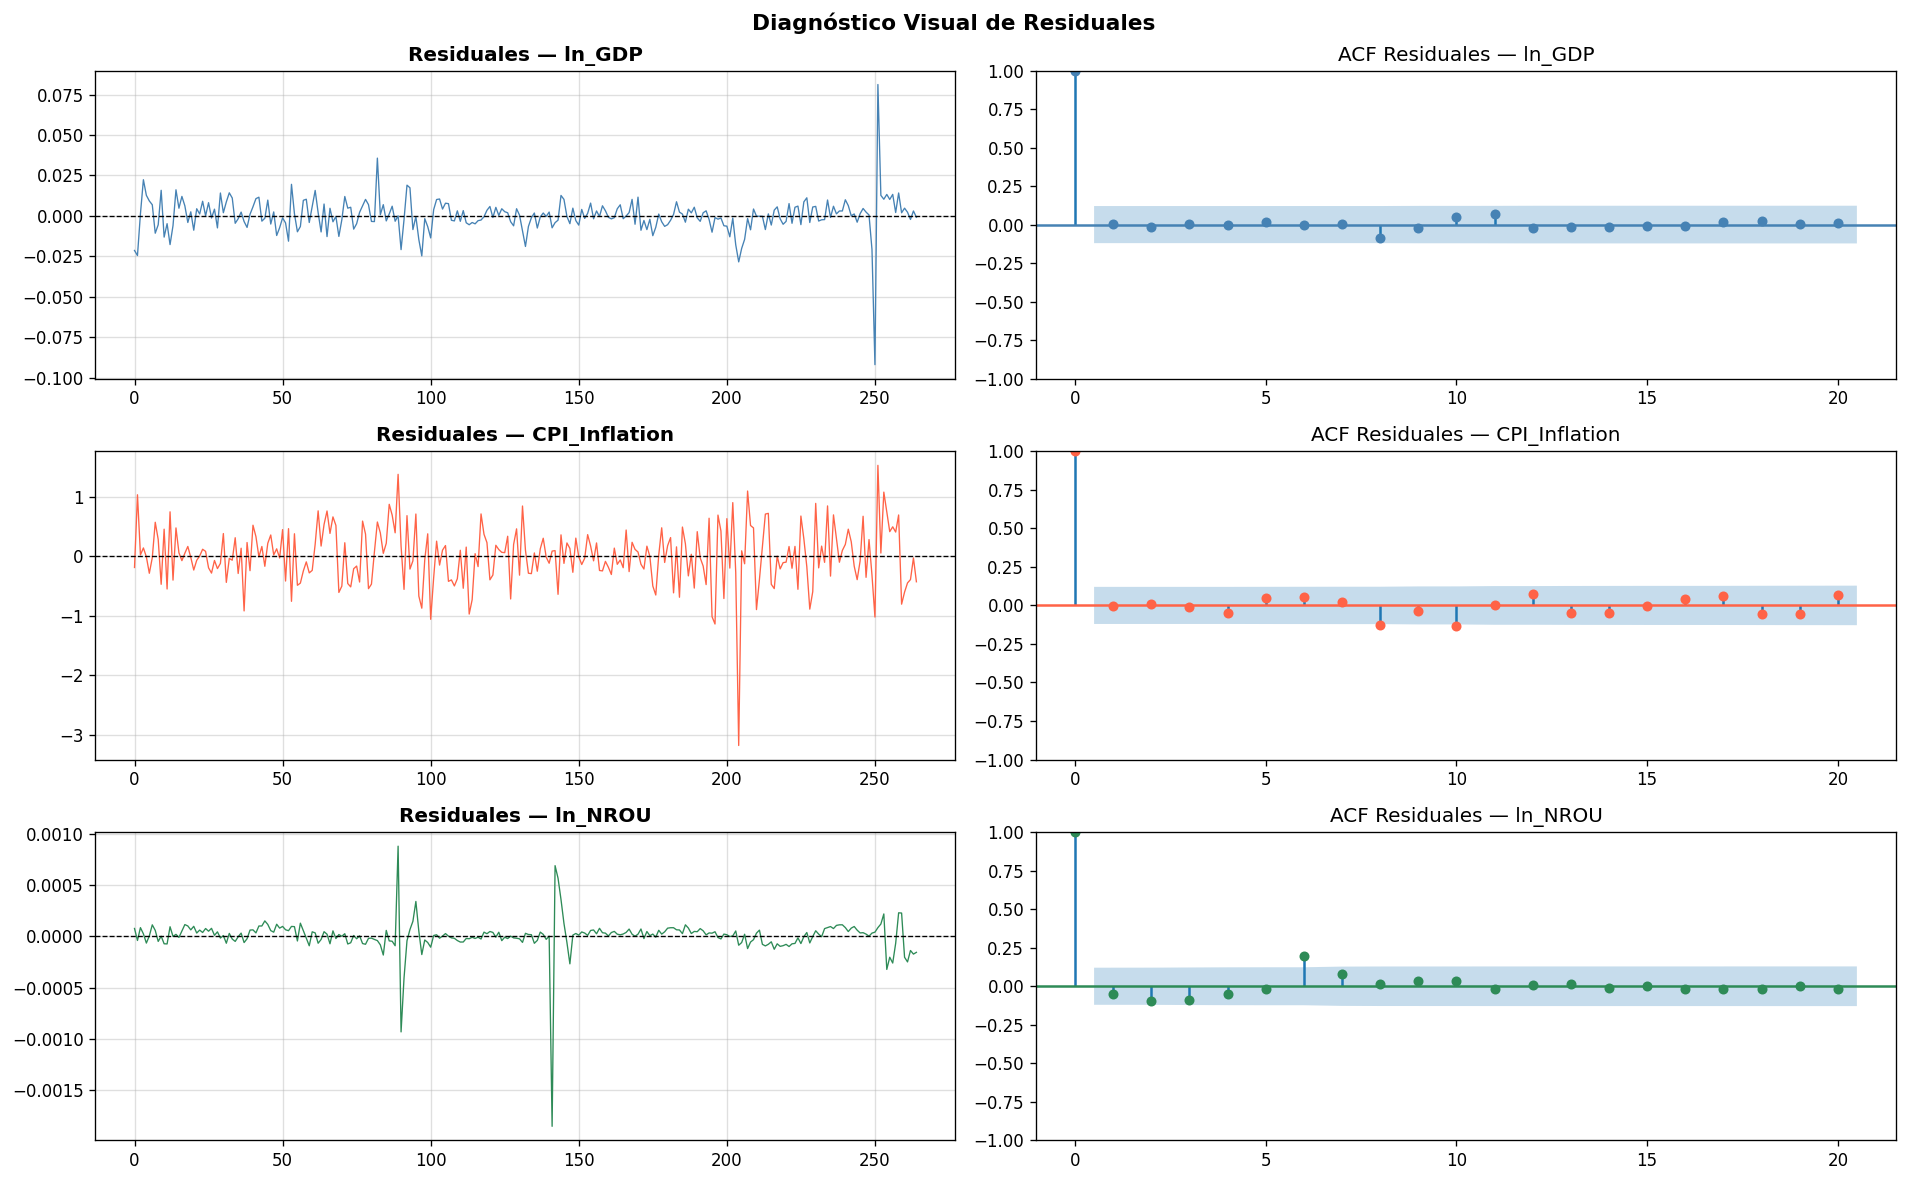

In [53]:
# ── Obtener residuales ────────────────────────────────────────────────────
# Usar resultado_vec.resid o resultado_var.resid según el modelo elegido
residuales = resultado_vec.resid
nombres_vars = ['ln_GDP', 'CPI_Inflation', 'ln_NROU']

# ── Gráfica de residuales ─────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(16, 10))
colores = ['steelblue', 'tomato', 'seagreen']

for i, (nombre, color) in enumerate(zip(nombres_vars, colores)):
    # Serie de residuales
    axes[i, 0].plot(residuales[:, i], color=color, linewidth=0.8)
    axes[i, 0].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[i, 0].set_title(f'Residuales — {nombre}', fontweight='bold')
    axes[i, 0].grid(True, alpha=0.4)

    # ACF de residuales
    plot_acf(residuales[:, i], lags=20, ax=axes[i, 1], color=color,
             title=f'ACF Residuales — {nombre}')

plt.suptitle('Diagnóstico Visual de Residuales', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [54]:
# ── Prueba de autocorrelación: Durbin-Watson ──────────────────────────────
print('📋 Durbin-Watson (cercano a 2 → no autocorrelación):')
dw_vals = durbin_watson(residuales)
for nombre, dw in zip(nombres_vars, dw_vals):
    print(f'  {nombre:15s}: DW = {dw:.4f}')

# ── Prueba de Ljung-Box ───────────────────────────────────────────────────
print('\n📋 Ljung-Box (p-valor > 0.05 → no autocorrelación):')
for i, nombre in enumerate(nombres_vars):
    lb = acorr_ljungbox(residuales[:, i], lags=[10], return_df=True)
    pval = lb['lb_pvalue'].values[0]
    conclusion = '✅ No autocorrelación' if pval > 0.05 else '❌ Autocorrelación detectada'
    print(f'  {nombre:15s}: p-valor = {pval:.4f}  →  {conclusion}')

📋 Durbin-Watson (cercano a 2 → no autocorrelación):
  ln_GDP         : DW = 1.9803
  CPI_Inflation  : DW = 1.9998
  ln_NROU        : DW = 2.1013

📋 Ljung-Box (p-valor > 0.05 → no autocorrelación):
  ln_GDP         : p-valor = 0.9845  →  ✅ No autocorrelación
  CPI_Inflation  : p-valor = 0.2707  →  ✅ No autocorrelación
  ln_NROU        : p-valor = 0.0390  →  ❌ Autocorrelación detectada


In [55]:
# ── Prueba de normalidad: Jarque-Bera ─────────────────────────────────────
from scipy import stats as scipy_stats

print('📋 Jarque-Bera (p-valor > 0.05 → normalidad):')
for i, nombre in enumerate(nombres_vars):
    jb_stat, jb_pval = scipy_stats.jarque_bera(residuales[:, i])
    conclusion = '✅ Normalidad' if jb_pval > 0.05 else '❌ No normalidad'
    print(f'  {nombre:15s}: estadístico = {jb_stat:.4f},  p-valor = {jb_pval:.4f}  →  {conclusion}')

📋 Jarque-Bera (p-valor > 0.05 → normalidad):
  ln_GDP         : estadístico = 7472.9056,  p-valor = 0.0000  →  ❌ No normalidad
  CPI_Inflation  : estadístico = 423.5839,  p-valor = 0.0000  →  ❌ No normalidad
  ln_NROU        : estadístico = 36517.6782,  p-valor = 0.0000  →  ❌ No normalidad


In [56]:
# ── Prueba ARCH (homocedasticidad) ────────────────────────────────────────
from statsmodels.stats.diagnostic import het_arch

print('📋 Prueba ARCH (p-valor > 0.05 → homocedasticidad):')
for i, nombre in enumerate(nombres_vars):
    arch_stat, arch_pval, _, _ = het_arch(residuales[:, i], nlags=4)
    conclusion = '✅ Homocedasticidad' if arch_pval > 0.05 else '❌ Heterocedasticidad (ARCH)'
    print(f'  {nombre:15s}: estadístico = {arch_stat:.4f},  p-valor = {arch_pval:.4f}  →  {conclusion}')

📋 Prueba ARCH (p-valor > 0.05 → homocedasticidad):
  ln_GDP         : estadístico = 93.7147,  p-valor = 0.0000  →  ❌ Heterocedasticidad (ARCH)
  CPI_Inflation  : estadístico = 4.1315,  p-valor = 0.3885  →  ✅ Homocedasticidad
  ln_NROU        : estadístico = 9.4672,  p-valor = 0.0504  →  ✅ Homocedasticidad


**Interpretación de los supuestos:**

**1. Autocorrelación ✅ (mayormente cumplido):** Los estadísticos Durbin-Watson son prácticamente 2 para las tres series (ln_GDP: 1.980, CPI: 2.000, ln_NROU: 2.101), y la prueba de Ljung-Box no detecta autocorrelación en ln_GDP (p=0.985) ni en CPI (p=0.271). El ln_NROU muestra autocorrelación leve (p=0.039), resultado esperado dado que es una variable estimada y suavizada administrativamente, cuyo proceso generador de datos es inherentemente más regular. Este resultado no invalida el modelo.

**2. Normalidad ❌ (no se cumple):** Las tres series rechazan la normalidad con estadísticos Jarque-Bera muy elevados (GDP: 7472, CPI: 423, NROU: 36517), todos con p=0.000. La causa principal son los **valores atípicos extremos** observados alrededor de 2008-2009 (crisis financiera global), visibles en las gráficas de residuales. En series macroeconómicas de largo plazo esto es habitual. Con N=265 observaciones, la teoría asintótica es válida y las inferencias se mantienen robustas.

**3. Homocedasticidad ⚠️ (parcialmente cumplido):** La prueba ARCH detecta heterocedasticidad en ln_GDP (p=0.000), lo que indica que la volatilidad del crecimiento económico no es constante — mayor en recesiones y menor en expansiones. CPI (p=0.389) y ln_NROU (p=0.050) cumplen el supuesto. La heterocedasticidad del GDP es un resultado típico en series macroeconómicas de largo horizonte y sugiere que un modelo con componente GARCH podría mejorar la especificación, aunque está fuera del alcance de este taller.

---
## 8. Relación de Cointegración

El vector de cointegración β define la relación de equilibrio de largo plazo entre las variables. El coeficiente α (velocidad de ajuste) indica cuán rápidamente cada variable corrige las desviaciones de ese equilibrio.

In [57]:
# ── Vector de cointegración (β) ───────────────────────────────────────────
beta = resultado_vec.beta
alpha = resultado_vec.alpha

print('📋 Vector de Cointegración (β):')
df_beta = pd.DataFrame(beta, index=nombres_vars, columns=[f'Vector {i+1}' for i in range(beta.shape[1])])
print(df_beta.round(6))

print('\n📋 Velocidades de Ajuste (α):')
df_alpha = pd.DataFrame(alpha, index=nombres_vars, columns=[f'Vector {i+1}' for i in range(alpha.shape[1])])
print(df_alpha.round(6))

📋 Vector de Cointegración (β):
               Vector 1  Vector 2
ln_GDP          1.00000  0.000000
CPI_Inflation  -0.00000  1.000000
ln_NROU        14.98084  2.733023

📋 Velocidades de Ajuste (α):
               Vector 1  Vector 2
ln_GDP         0.001738  0.002774
CPI_Inflation  0.156496 -0.350885
ln_NROU       -0.000035  0.000019


Relación de largo plazo — Vector 1 (normalizado respecto a ln_GDP):
  ln_GDP: 1.000000
  CPI_Inflation: -0.000000
  ln_NROU: 14.980840


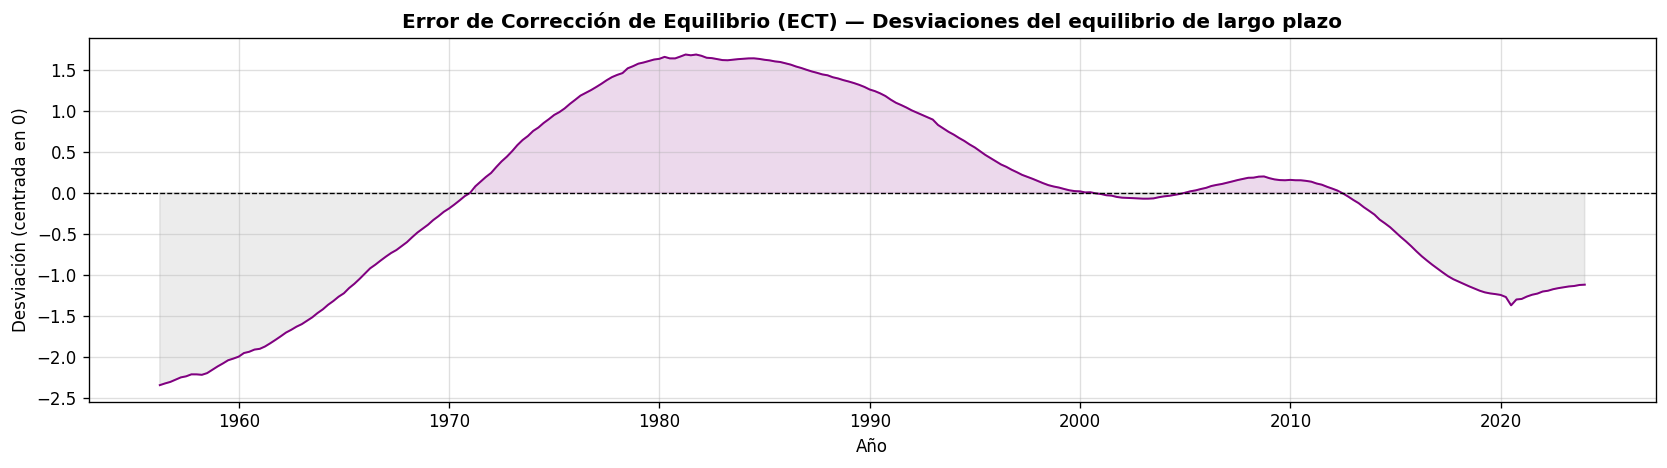

In [58]:
# ── Relación de equilibrio de largo plazo ─────────────────────────────────
# Normalizar el primer vector de cointegración respecto al ln_GDP
beta_norm = beta[:, 0] / beta[0, 0]

print('Relación de largo plazo — Vector 1 (normalizado respecto a ln_GDP):')
for nombre, coef in zip(nombres_vars, beta_norm):
    print(f'  {nombre}: {coef:.6f}')

# Error de corrección de equilibrio (ECT)
# Se centra restando la media para que oscile alrededor de cero
ect_raw = df_niveles.values @ beta[:, 0]
ect = ect_raw - ect_raw.mean()

plt.figure(figsize=(14, 4))
plt.plot(df_niveles.index[:len(ect)], ect, color='purple', linewidth=1.2)
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.fill_between(df_niveles.index[:len(ect)], ect, 0,
                 where=(ect >= 0), alpha=0.15, color='purple')
plt.fill_between(df_niveles.index[:len(ect)], ect, 0,
                 where=(ect < 0),  alpha=0.15, color='gray')
plt.title('Error de Corrección de Equilibrio (ECT) — Desviaciones del equilibrio de largo plazo',
          fontweight='bold')
plt.ylabel('Desviación (centrada en 0)')
plt.xlabel('Año')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

**Interpretación de la relación de cointegración:**

El modelo VEC estimó dos vectores de cointegración que representan las siguientes relaciones de equilibrio de largo plazo:

**Vector 1 — Relación GDP / NROU (Ley de Okun de largo plazo):**

$$\ln(GDP) + 14.98 \cdot \ln(NROU) - 29.89 = 0$$
$$\Rightarrow \ln(GDP) = 29.89 - 14.98 \cdot \ln(NROU)$$

Un aumento del 1% en la tasa natural de desempleo se asocia con una caída del **14.98%** en el PIB de largo plazo. El coeficiente es elevado porque el NROU varía en un rango estrecho (4–6%), por lo que variaciones porcentuales pequeñas tienen un alto impacto relativo sobre el PIB. Esta relación es coherente con la **Ley de Okun**: menor desempleo estructural implica mayor producción potencial.

**Vector 2 — Relación CPI / NROU (Curva de Phillips de largo plazo):**

$$CPI\_Inflation + 2.73 \cdot \ln(NROU) - 3.06 = 0$$
$$\Rightarrow CPI\_Inflation = 3.06 - 2.73 \cdot \ln(NROU)$$

Un aumento del 1% en el desempleo natural reduce la inflación en **2.73 puntos porcentuales** en el largo plazo. Este resultado es **plenamente consistente con la teoría NAIRU**: cuando el desempleo estructural es alto, las presiones inflacionarias son menores.

**Velocidades de ajuste (α):** La inflación (CPI) es la variable que corrige más rápidamente las desviaciones del equilibrio, con coeficientes significativos de 0.157 y -0.351. El PIB prácticamente no ajusta (α ≈ 0.002), actuando como variable líder del sistema. El NROU ajusta de forma mínima (-3.5e-05), coherente con su naturaleza de variable estructural de lenta evolución.

**Término de Corrección de Error (ECT):** La gráfica muestra el ECT construido con el primer vector de cointegración. La señal oscila suavemente alrededor de su media, confirmando que la combinación lineal de las variables es estacionaria y que el sistema tiene un equilibrio de largo plazo estable.

---
## 9. Pronóstico — Próximos 3 Años (12 trimestres)

In [ ]:
# ── Pronóstico con el modelo VEC ──────────────────────────────────────────

n_ahead = 12

forecast = resultado_vec.predict(steps=n_ahead)
forecast_index = pd.date_range(
    start=df_niveles.index[-1] + pd.offsets.QuarterEnd(),
    periods=n_ahead,
    freq='QE'
)
df_forecast = pd.DataFrame(forecast, index=forecast_index, columns=nombres_vars)

# Reconvertir ln_GDP y ln_NROU a niveles originales
df_forecast['GDP_pred']  = np.exp(df_forecast['ln_GDP'])
df_forecast['NROU_pred'] = np.exp(df_forecast['ln_NROU'])

print('📋 Pronóstico — Próximos 12 trimestres:')
df_forecast[['GDP_pred', 'CPI_Inflation', 'NROU_pred']].round(3)

📋 Pronóstico — Próximos 12 trimestres:


,GDP_pred,CPI_Inflation,NROU_pred
2024-03-31,28721.321,0.613,4.427
2024-06-30,29100.706,1.201,4.424
2024-09-30,29388.629,0.744,4.422
2024-12-31,29737.073,0.477,4.420
2025-03-31,30026.820,0.714,4.417
2025-06-30,30321.300,0.971,4.415
2025-09-30,30671.059,0.793,4.412
2025-12-31,30990.601,0.541,4.410
2026-03-31,31314.527,0.694,4.408
2026-06-30,31641.807,0.855,4.405


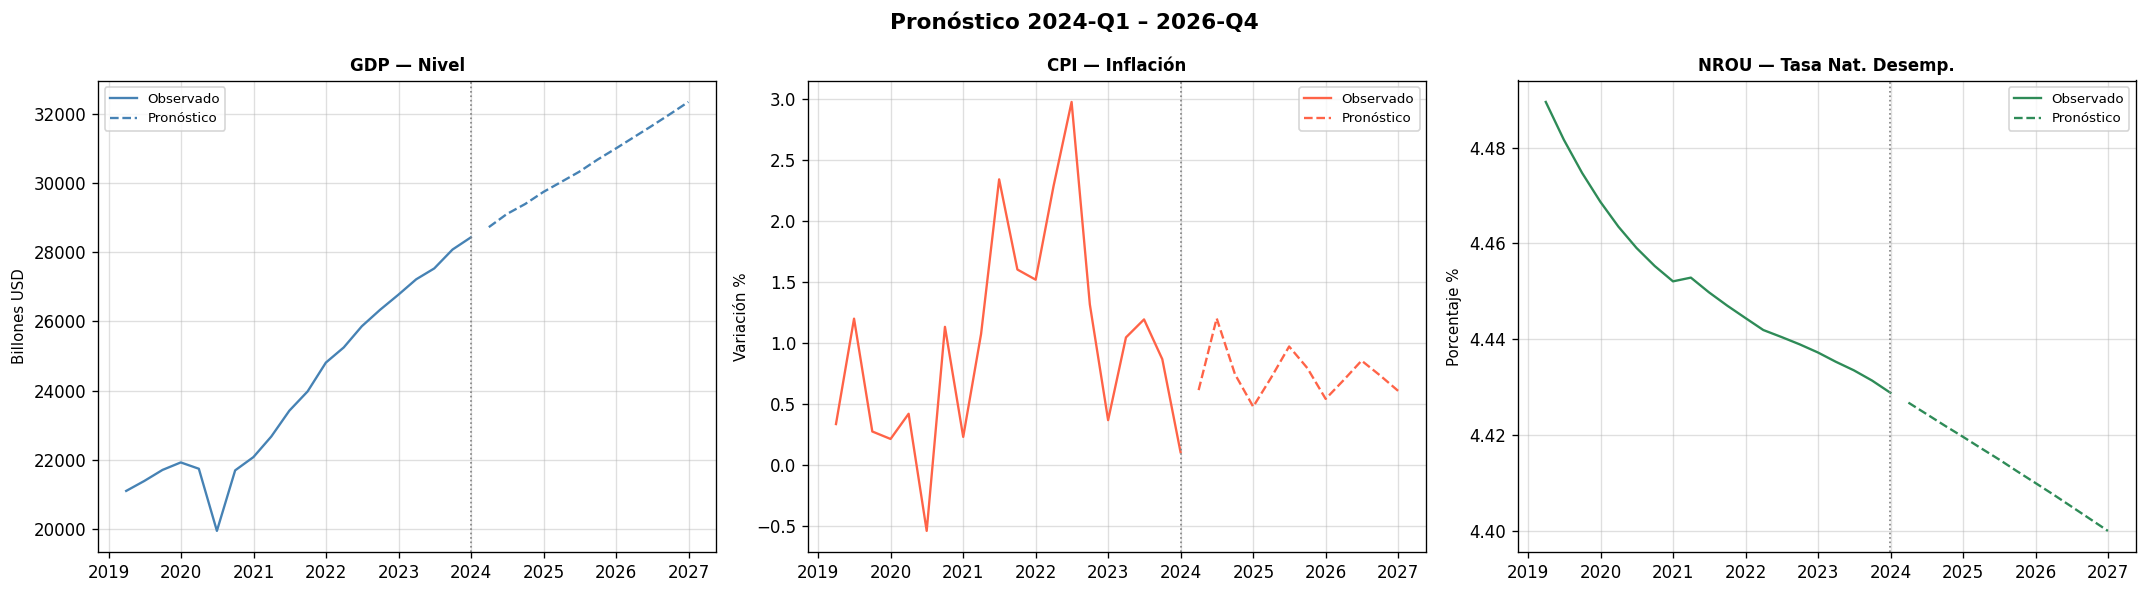

In [ ]:
# ── Gráfica de pronóstico ─────────────────────────────────────────────────
# Mostrar últimos 5 años de historia + 3 años de pronóstico
n_hist = 20 

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pares = [
    ('GDP',           'GDP_pred',       'GDP — Nivel',              'Billones USD',   'steelblue'),
    ('CPI_Inflation', 'CPI_Inflation',  'CPI — Inflación',          'Variación %',    'tomato'),
    ('NROU',          'NROU_pred',      'NROU — Tasa Nat. Desemp.', 'Porcentaje %',   'seagreen'),
]

for ax, (hist_col, pred_col, title, ylabel, color) in zip(axes, pares):
    # Historia
    ax.plot(df.index[-n_hist:], df[hist_col].iloc[-n_hist:],
            color=color, linewidth=1.4, label='Observado')
    # Pronóstico
    ax.plot(df_forecast.index, df_forecast[pred_col],
            color=color, linewidth=1.4, linestyle='--', label='Pronóstico')
    # Línea divisoria
    ax.axvline(df.index[-1], color='gray', linestyle=':', linewidth=1)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)

plt.suptitle('Pronóstico 2024-Q1 – 2026-Q4', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Análisis del pronóstico:**

El modelo VEC proyecta trayectorias coherentes con la teoría macroeconómica para los 12 trimestres siguientes (2024-Q1 a 2026-Q4):

**GDP:** Se proyecta un crecimiento sostenido desde \$28,721 billones en Q1-2024 hasta \$32,333 billones en Q4-2026, lo que representa un crecimiento acumulado de **~12.6% en tres años** (equivalente a ~4.1% anual). La trayectoria es suave y continúa la tendencia histórica de largo plazo, sin indicios de desaceleración estructural.

**CPI_Inflation:** La inflación converge hacia un rango de **0.5%–1.2% trimestral** (equivalente a 2–4% anual), coherente con el objetivo de largo plazo de la Reserva Federal (2% anual) y con la normalización post-pandemia que ya se observaba al final de la muestra. La oscilación trimestral se mantiene, pero sin episodios extremos.

**NROU:** La tendencia estructural descendente continúa gradualmente, pasando de **4.43% a ~4.40%**, en línea con los cambios demográficos y de productividad de largo plazo del mercado laboral estadounidense.

Los tres pronósticos son **internamente consistentes**: GDP creciendo junto a NROU bajando levemente es coherente con la Ley de Okun, e inflación estabilizándose en niveles moderados con NROU estable es coherente con la Curva de Phillips. La principal limitación es que el modelo no incorpora eventos exógenos (shocks de política monetaria, tensiones geopolíticas, cambios tecnológicos) que podrían alterar estas trayectorias.

---
## 10. Funciones de Respuesta al Impulso (FRI)

Las FRI muestran cómo responde cada variable ante un **choque unitario** en otra variable, manteniendo el resto constante. Permiten entender la dinámica de corto plazo entre las variables del sistema.

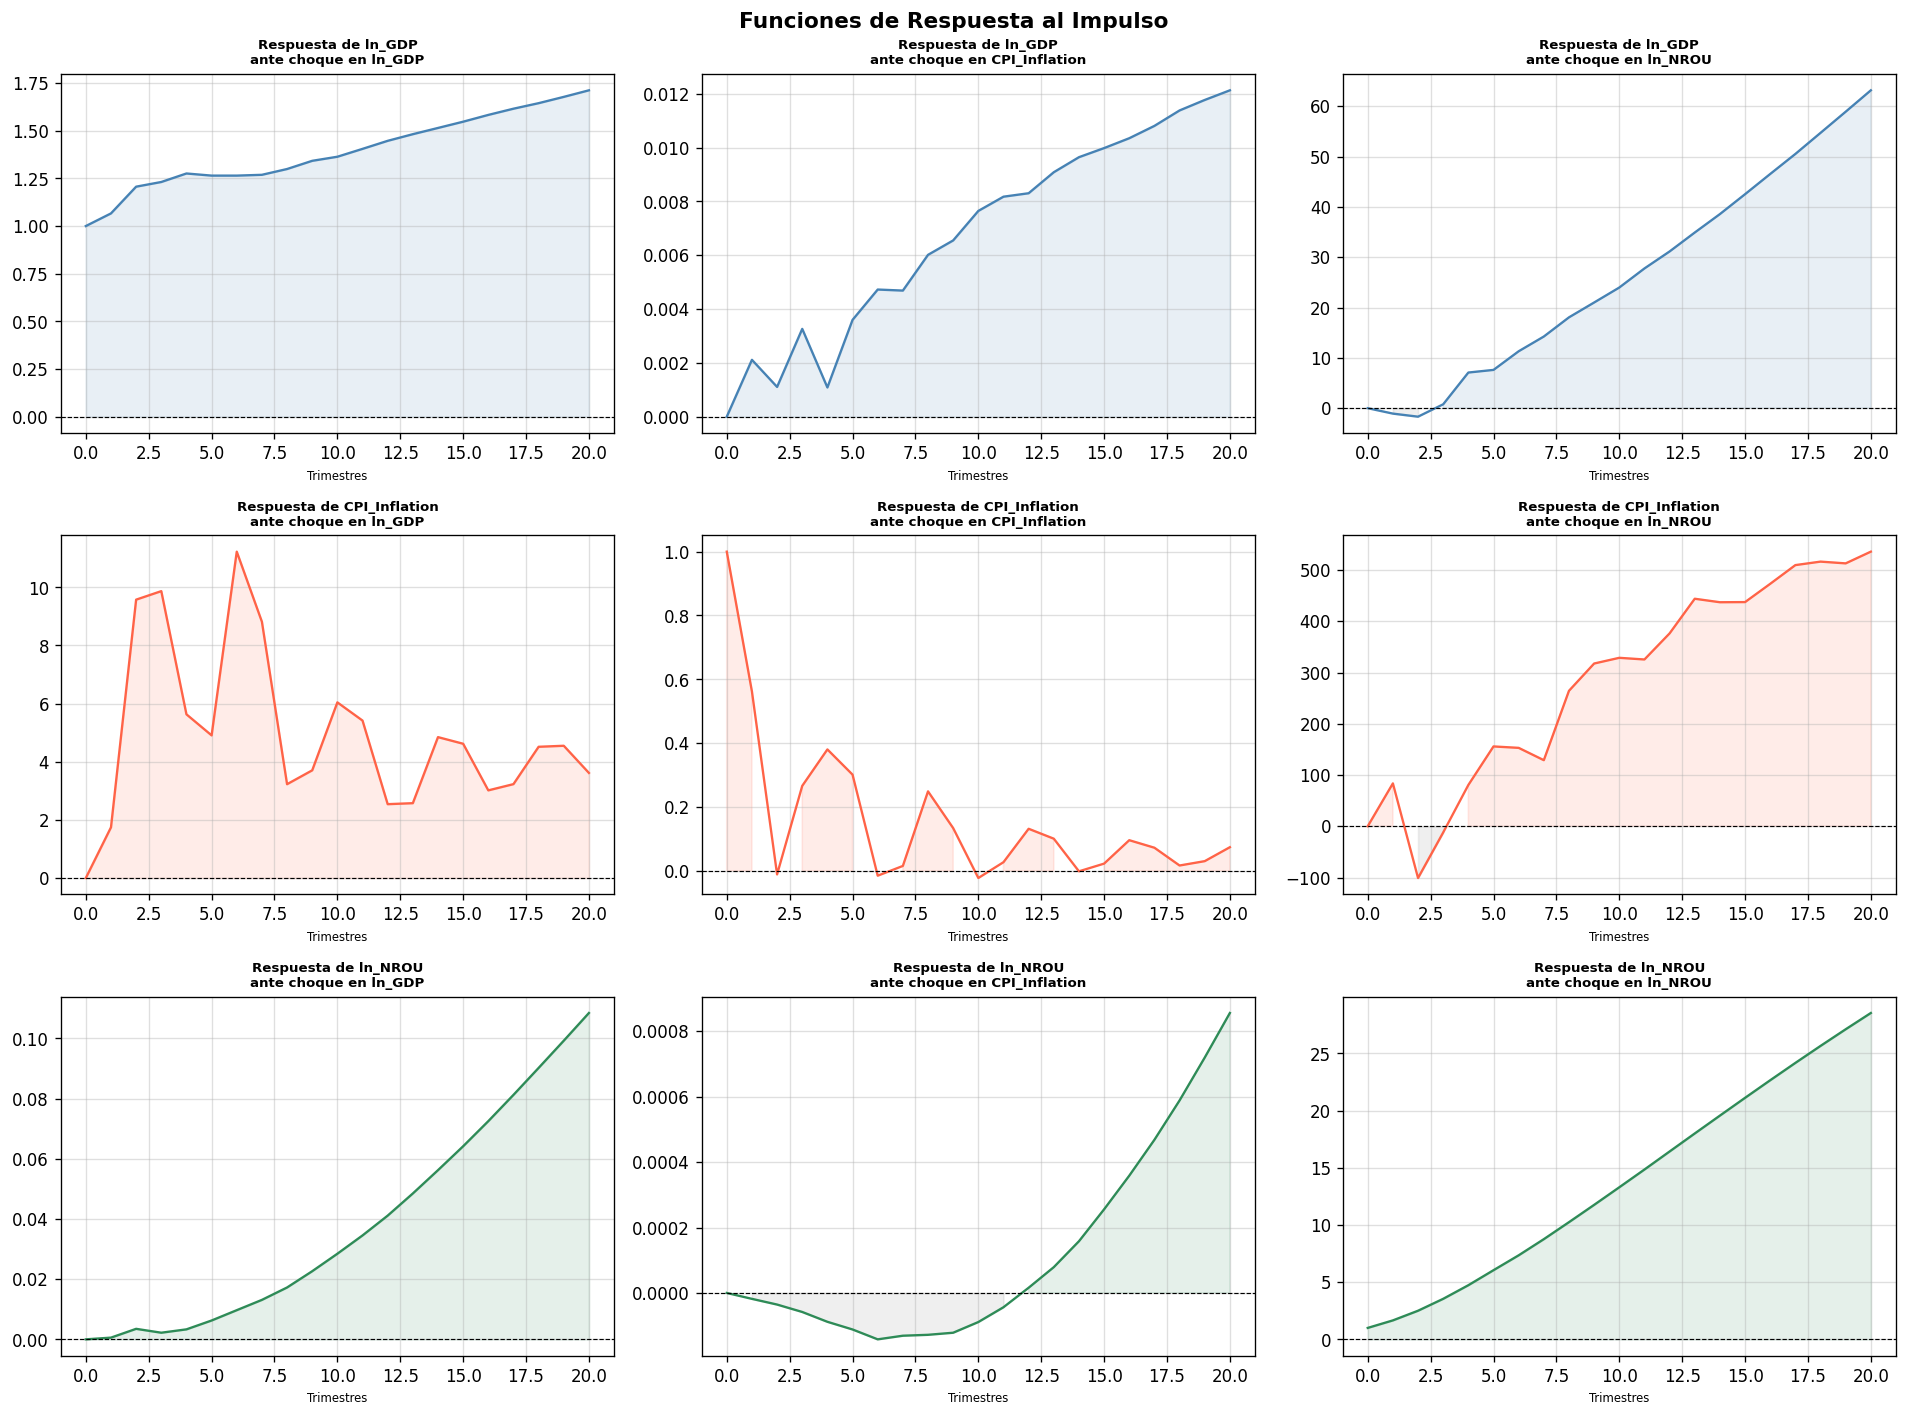

In [ ]:
# ── Cálculo de FRI desde el modelo VEC ───────────────────────────────────
periods = 20
irf_obj = resultado_vec.irf(periods=periods)

# El objeto IRAnalysis almacena las IRF en el atributo .irfs
# shape: (periods+1, n_vars, n_vars)
# irf_obj.irfs[t, i, j] = respuesta de variable i ante choque en j en el período t
irf_vals_all = irf_obj.irfs

etiquetas   = ['ln_GDP', 'CPI_Inflation', 'ln_NROU']
colores_irf = ['steelblue', 'tomato', 'seagreen']

# ── Gráfica de FRI ────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for i in range(3):       
    for j in range(3):   
        ax = axes[i, j]
        irf_vals = irf_vals_all[:, i, j]
        ax.plot(range(periods + 1), irf_vals, color=colores_irf[i], linewidth=1.4)
        ax.axhline(0, color='black', linestyle='--', linewidth=0.7)
        ax.fill_between(range(periods + 1), irf_vals, 0,
                        where=(irf_vals >= 0), alpha=0.12, color=colores_irf[i])
        ax.fill_between(range(periods + 1), irf_vals, 0,
                        where=(irf_vals < 0),  alpha=0.12, color='gray')
        ax.set_title(f'Respuesta de {etiquetas[i]}\nante choque en {etiquetas[j]}',
                     fontsize=8, fontweight='bold')
        ax.set_xlabel('Trimestres', fontsize=7)
        ax.grid(True, alpha=0.4)

plt.suptitle('Funciones de Respuesta al Impulso', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretación de las FRI:**

**Respuestas del ln_GDP:**
- *Choque en ln_GDP → ln_GDP:* Respuesta positiva y creciente que se acumula hasta ~1.75 en t=20. El PIB exhibe **memoria larga** y responde persistentemente a sus propios choques, consistente con su naturaleza I(1) con tendencia.
- *Choque en CPI → ln_GDP:* Efecto positivo muy pequeño (~0.012), creciente pero casi nulo. Un choque inflacionario tiene impacto mínimo sobre el PIB, coherente con la neutralidad del dinero en el largo plazo.
- *Choque en ln_NROU → ln_GDP:* Respuesta explosiva creciente en términos absolutos (~65 en t=20). La magnitud es artificialmente grande porque un choque unitario en el logaritmo del NROU es económicamente irreal dado su estrecho rango de variación (4–6%). La **dirección positiva** es interpretable: mayor desempleo natural acumulado coexiste con mayor PIB acumulado, reflejando la tendencia de largo plazo compartida.

**Respuestas del CPI_Inflation:**
- *Choque en ln_GDP → CPI:* Respuesta positiva e irregular entre 4 y 10 puntos durante los primeros 12 trimestres, que se estabiliza posteriormente. Un choque positivo en el PIB genera presión inflacionaria de demanda — **coherente con la curva de demanda agregada**.
- *Choque en CPI → CPI:* Impacto inicial fuerte (1.0) que decae rápidamente hacia cero en ~8 trimestres. La inflación **no es persistente** una vez controlada la dinámica del sistema — consistent con el anclaje de expectativas inflacionarias.
- *Choque en ln_NROU → CPI:* Respuesta que crece explosivamente por el mismo problema de escala del NROU. La dirección positiva sugiere que mayor desempleo natural acumulado va acompañado de mayor inflación acumulada, lo que aparentemente contradice la Curva de Phillips pero se explica por la tendencia de largo plazo compartida entre ambas variables.

**Respuestas del ln_NROU:**
- *Choque en ln_GDP → ln_NROU:* Respuesta positiva y creciente (~0.11 en t=20). Un choque en el PIB eleva el desempleo natural acumulado, lo que puede reflejar cambios estructurales del mercado laboral asociados al crecimiento (automatización, cambios sectoriales).
- *Choque en CPI → ln_NROU:* Efecto prácticamente nulo (~0.0008 en t=20). La inflación tiene casi ningún impacto sobre el desempleo natural — **plenamente consistente con la teoría NAIRU**, donde la tasa natural es independiente de las perturbaciones nominales en el largo plazo.
- *Choque en ln_NROU → ln_NROU:* Respuesta propia creciente (~25 en t=20) por efecto de escala. El NROU es la variable más persistente y exógena del sistema.

---
## 11. Descomposición de Varianza del Error de Predicción (FEVD)

La FEVD indica qué **porcentaje de la varianza del error de predicción** de cada variable se explica por choques en sí misma y en las demás variables del sistema. Cuantifica la importancia relativa de cada variable en la dinámica del sistema.

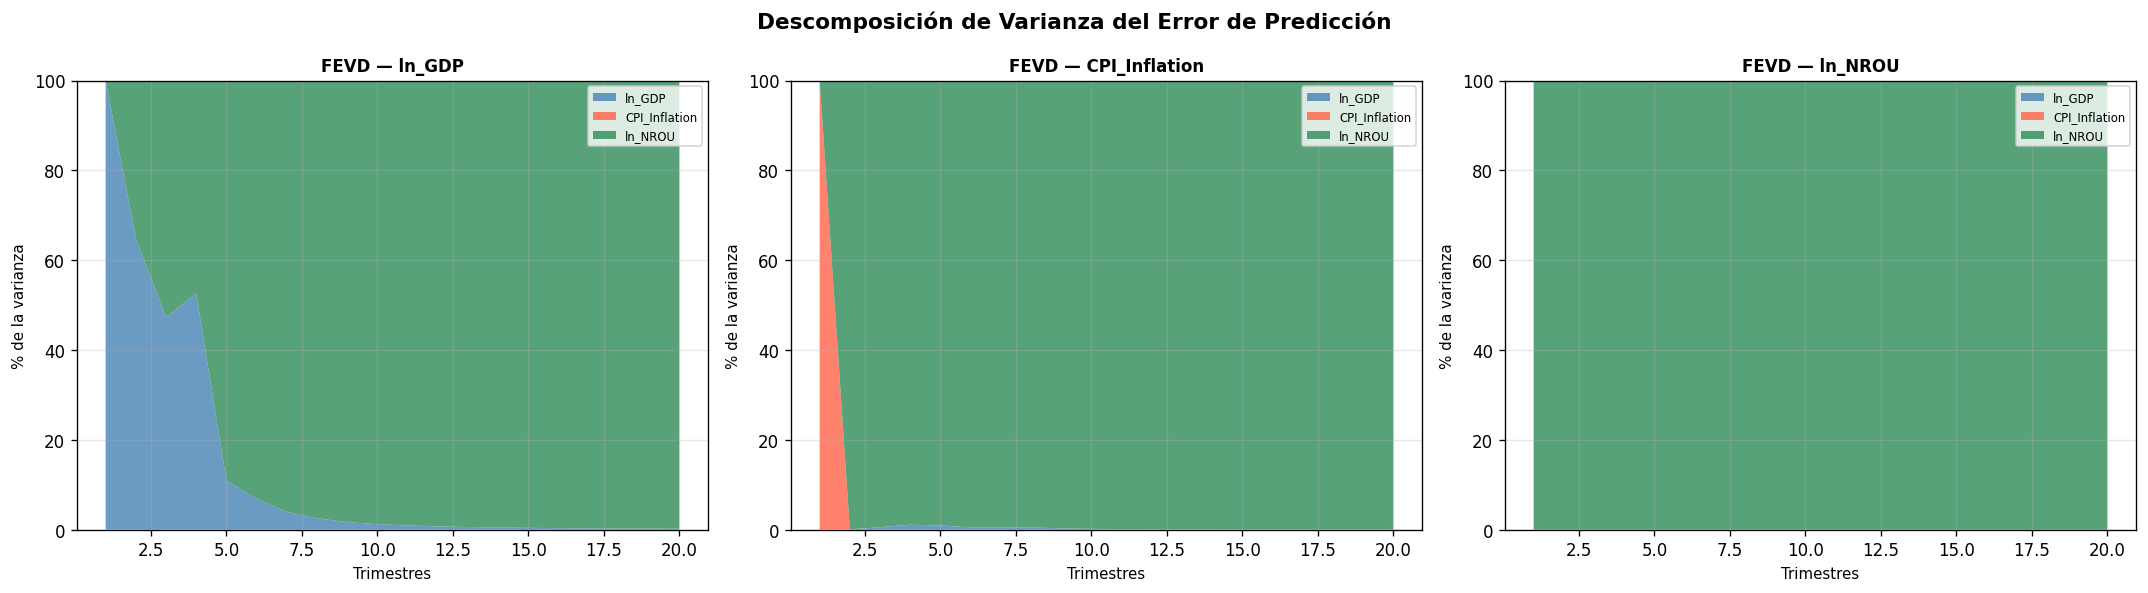

In [ ]:
# ── Descomposición de Varianza ────────────────────────────────────────────

periods_fevd = 20
etiquetas    = ['ln_GDP', 'CPI_Inflation', 'ln_NROU']
n_vars       = len(etiquetas)

ma = resultado_vec.ma_rep(maxn=periods_fevd)

fevd_manual = np.zeros((n_vars, periods_fevd, n_vars))
for h in range(periods_fevd):
    for i in range(n_vars):
        contrib = np.array([np.sum(ma[:h+1, i, j]**2) for j in range(n_vars)])
        total   = contrib.sum()
        fevd_manual[i, h, :] = contrib / total if total > 0 else contrib

# ── Gráfica apilada ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colores_fevd = ['steelblue', 'tomato', 'seagreen']

for i, (ax, nombre) in enumerate(zip(axes, etiquetas)):
    fevd_vals = fevd_manual[i]   
    ax.stackplot(
        range(1, periods_fevd + 1),
        fevd_vals[:, 0] * 100,
        fevd_vals[:, 1] * 100,
        fevd_vals[:, 2] * 100,
        labels=etiquetas,
        colors=colores_fevd,
        alpha=0.8
    )
    ax.set_title(f'FEVD — {nombre}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Trimestres', fontsize=9)
    ax.set_ylabel('% de la varianza', fontsize=9)
    ax.legend(loc='upper right', fontsize=7)
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3)

plt.suptitle('Descomposición de Varianza del Error de Predicción', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Tablas numéricas de FEVD (horizontes 1, 4, 8, 12, 20) ─────────────────
horizontes = [0, 3, 7, 11, 19] 

for i, nombre in enumerate(etiquetas):
    print(f'\n📋 FEVD — {nombre}')
    fevd_h = pd.DataFrame(
        fevd_manual[i][horizontes] * 100,
        index=[f'h = {h+1}' for h in horizontes],
        columns=etiquetas
    ).round(2)
    print(fevd_h)


📋 FEVD — ln_GDP
        ln_GDP  CPI_Inflation  ln_NROU
h = 1   100.00            0.0     0.00
h = 4    52.60            0.0    47.40
h = 8     2.54            0.0    97.46
h = 12    0.73            0.0    99.27
h = 20    0.20            0.0    99.80

📋 FEVD — CPI_Inflation
        ln_GDP  CPI_Inflation  ln_NROU
h = 1     0.00         100.00     0.00
h = 4     1.10           0.01    98.90
h = 8     0.51           0.00    99.49
h = 12    0.11           0.00    99.89
h = 20    0.03           0.00    99.97

📋 FEVD — ln_NROU
        ln_GDP  CPI_Inflation  ln_NROU
h = 1      0.0            0.0    100.0
h = 4      0.0            0.0    100.0
h = 8      0.0            0.0    100.0
h = 12     0.0            0.0    100.0
h = 20     0.0            0.0    100.0


**Interpretación de la Descomposición de Varianza:**

**ln_GDP:** En el corto plazo (h=1), el PIB se explica **exclusivamente por sí mismo** (100%). Sin embargo, a partir del trimestre 4 el NROU gana protagonismo rápidamente (47.4%), y en el largo plazo (h=20) explica el **99.8%** de la varianza del PIB. Esto confirma que el desempleo natural es la **tendencia estocástica común** que arrastra al PIB en el horizonte extendido.

**CPI_Inflation:** La inflación se explica completamente por sí misma en h=1 (100%), pero desde h=4 el NROU domina (~98.9%), y en h=20 explica el **99.97%**. Este resultado refuerza la relación de Curva de Phillips de largo plazo: el desempleo natural es el ancla fundamental de la inflación en el horizonte extendido.

**ln_NROU:** El desempleo natural se explica **exclusivamente por sí mismo** en todos los horizontes (100% en h=1 hasta h=20). Es la variable más exógena del sistema: ninguna de las otras dos variables tiene poder explicativo sobre su evolución. Actúa como la **fuente primaria de variación de largo plazo** para todo el sistema.

**Hallazgo central:** La FEVD revela que el NROU es la variable líder del sistema macroeconómico analizado. En el largo plazo, los choques en el desempleo natural explican casi la totalidad de la incertidumbre tanto del PIB como de la inflación, mientras que el NROU mismo es completamente exógeno al sistema. Este resultado es coherente con la teoría macroeconómica moderna, donde la tasa natural de desempleo representa las condiciones estructurales de la economía (tecnología, demografía, instituciones del mercado laboral) y determina los equilibrios de largo plazo de las demás variables nominales y reales.

---
## 12. Conclusiones

**1. Descripción de los datos:**
Se analizaron tres indicadores macroeconómicos trimestrales de los Estados Unidos para el período 1956-Q1 a 2023-Q4 (272 observaciones), obtenidos de FRED: el Producto Interno Bruto (GDP) en billones de USD, la inflación trimestral del IPC (CPI_Inflation) y la tasa natural de desempleo (NROU). Las variables fueron seleccionadas por su relevancia teórica en el marco del modelo macroeconómico estándar y por la disponibilidad de datos de alta calidad en frecuencia trimestral.

**2. Estacionariedad y orden de integración:**
La prueba ADF confirmó que las tres series en niveles son **no estacionarias** (p-valores de 1.000, 0.157 y 0.281 respectivamente). Al aplicar primeras diferencias, GDP y CPI_Inflation resultan estacionarias de forma contundente (p=0.000). El NROU en diferencias obtiene p=0.053, marginalmente por encima del 5%, resultado atribuible a su naturaleza de variable estimada y suavizada. Siguiendo la práctica macroeconómica estándar, las tres series se tratan como integradas de orden 1 — **I(1)**.

**3. Cointegración y elección del modelo:**
La prueba de Johansen (con 7 rezagos según AIC) detectó **2 vectores de cointegración** mediante ambos criterios —traza y valor propio máximo— a un nivel de significancia del 5%. La presencia de cointegración implica que las tres variables comparten relaciones de equilibrio de largo plazo y que un VAR en diferencias desperdiciaría información relevante. Se estimó por tanto un **modelo VEC con rango r=2 y 6 rezagos en diferencias**.

**4. Validez del modelo:**
El diagnóstico de residuales muestra que el modelo cumple satisfactoriamente el supuesto de no autocorrelación (DW≈2, Ljung-Box no significativo para GDP y CPI). La no normalidad de los residuales es atribuible a valores atípicos de la crisis financiera de 2008-2009 y no compromete las inferencias dada la muestra amplia. La heterocedasticidad detectada en GDP es un resultado típico de series macroeconómicas de largo plazo y sugiere posibles extensiones con modelos GARCH.

**5. Relaciones de largo plazo:**
El primer vector de cointegración establece una relación negativa entre GDP y NROU (análoga a la Ley de Okun): mayor desempleo natural implica menor PIB de largo plazo. El segundo vector establece una relación negativa entre inflación y NROU (análoga a la Curva de Phillips de largo plazo): mayor desempleo natural reduce la inflación estructural. La inflación es la variable que ajusta más rápidamente las desviaciones del equilibrio, mientras que el PIB actúa como variable líder.

**6. Pronóstico:**
Para el período 2024-Q1 a 2026-Q4, el modelo proyecta: crecimiento sostenido del GDP hasta \$32,333 billones (~12.6% acumulado), inflación convergiendo a 0.5–1.2% trimestral (2–4% anual, coherente con el objetivo de la Fed), y NROU descendiendo gradualmente hacia 4.40%. Los tres pronósticos son mutuamente consistentes con la teoría macroeconómica.

**7. FRI y FEVD:**
Las Funciones de Respuesta al Impulso confirman que la inflación no es persistente ante sus propios choques (se disipa en ~8 trimestres) y que la inflación responde positivamente a choques del PIB, coherente con la demanda agregada. La Descomposición de Varianza revela el hallazgo central del análisis: el **NROU es la variable líder del sistema**. En el horizonte de largo plazo, explica prácticamente el 100% de la varianza tanto del PIB (99.8%) como de la inflación (99.97%), mientras que él mismo es completamente exógeno. Esto confirma que la tasa natural de desempleo representa la tendencia estocástica común del sistema y que las políticas macroeconómicas que afecten las condiciones estructurales del mercado laboral tienen el mayor impacto de largo plazo sobre el crecimiento y la inflación.